# Notebook 04 — Analyse Exploratoire des Données (EDA)

## Objectif

L'objectif de ce notebook est d'explorer les données analytiques
afin de comprendre les performances des patients pendant leurs
sessions de rééducation.

Nous allons notamment analyser :

- les scores obtenus ;
- les taux de réussite ;
- la durée des sessions ;
- le nombre de répétitions ;
- les performances des patients ;
- les exercices et les jeux ;
- l'évolution des performances au cours du temps.

L'objectif final est d'identifier des tendances et des premiers
insights utiles pour la création du dashboard destiné aux thérapeutes.

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [88]:
PROCESSED_PATH = "../data/processed/"
session_analysis = pd.read_csv(
    PROCESSED_PATH + "session_analysis.csv"
)

In [89]:
print("Dataset chargé avec succès.")
print("Dimensions :", session_analysis.shape)

Dataset chargé avec succès.
Dimensions : (500, 36)


In [90]:
session_analysis.head()

,id_assignment,patient_id,exercise_id,start_level_id,current_level_id,assigned_by,assigned_at,is_active,id_patient,first_name,...,id_session,patient_exercise_id,exercise_level_id,session_date,duration,score,session_id,repetitions,success_rate,progression
0,1,1,7,20,21,3,2026-04-26 11:12:54,True,1,Yasmine,...,1,1,20,2026-04-30 15:50:31,4,60.6,1,9,60.2,NaN
1,1,1,7,20,21,3,2026-04-26 11:12:54,True,1,Yasmine,...,2,1,20,2026-05-04 15:00:15,8,52.5,2,9,52.7,-13.37
2,1,1,7,20,21,3,2026-04-26 11:12:54,True,1,Yasmine,...,4,1,20,2026-05-07 15:00:09,5,63.8,4,10,68.7,21.52
3,1,1,7,20,21,3,2026-04-26 11:12:54,True,1,Yasmine,...,6,1,20,2026-05-12 15:10:22,4,60.3,6,6,59.0,-5.49
4,1,1,7,20,21,3,2026-04-26 11:12:54,True,1,Yasmine,...,8,1,20,2026-05-16 10:45:20,9,62.7,8,11,70.3,3.98


In [91]:
session_analysis.columns

Index(['id_assignment', 'patient_id', 'exercise_id', 'start_level_id',
       'current_level_id', 'assigned_by', 'assigned_at', 'is_active',
       'id_patient', 'first_name', 'last_name', 'date_of_birth', 'id_exercise',
       'game_id', 'name', 'description', 'id_game', 'name_game', 'body_part',
       'description_game', 'id_current_level', 'level_number', 'title',
       'target_angle', 'required_score', 'required_progression', 'id_session',
       'patient_exercise_id', 'exercise_level_id', 'session_date', 'duration',
       'score', 'session_id', 'repetitions', 'success_rate', 'progression'],
      dtype='object')

In [92]:
session_analysis.dtypes

id_assignment             int64
patient_id                int64
exercise_id               int64
start_level_id            int64
current_level_id          int64
assigned_by               int64
assigned_at              object
is_active                  bool
id_patient                int64
first_name               object
last_name                object
date_of_birth            object
id_exercise               int64
game_id                   int64
name                     object
description              object
id_game                   int64
name_game                object
body_part                object
description_game         object
id_current_level          int64
level_number              int64
title                    object
target_angle            float64
required_score          float64
required_progression    float64
id_session                int64
patient_exercise_id       int64
exercise_level_id         int64
session_date             object
duration                  int64
score   

In [93]:
session_analysis["session_date"] = pd.to_datetime(
    session_analysis["session_date"]
)

In [94]:
print(session_analysis["session_date"].dtype)

datetime64[ns]


In [95]:
session_analysis.describe()

,id_assignment,patient_id,exercise_id,start_level_id,current_level_id,assigned_by,id_patient,id_exercise,game_id,id_game,...,id_session,patient_exercise_id,exercise_level_id,session_date,duration,score,session_id,repetitions,success_rate,progression
count,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500,500.000000,500.000000,500.000000,500.000000,500.000000,457.000000
mean,20.806000,9.258000,5.352000,14.512000,15.30000,2.362000,9.258000,5.352000,2.190000,2.190000,...,250.500000,20.806000,14.800000,2026-08-02 14:23:15.533999872,7.842000,56.777800,250.500000,14.164000,57.340800,3.003961
min,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,2026-04-30 15:50:31,3.000000,24.200000,1.000000,5.000000,24.600000,-49.860000
25%,11.000000,5.000000,4.000000,10.000000,12.00000,2.000000,5.000000,4.000000,2.000000,2.000000,...,125.750000,11.000000,11.000000,2026-07-13 02:04:07,7.000000,51.200000,125.750000,12.000000,51.775000,-5.110000
50%,21.000000,8.000000,6.000000,16.000000,17.00000,3.000000,8.000000,6.000000,2.000000,2.000000,...,250.500000,21.000000,17.000000,2026-08-08 10:00:07,8.000000,56.750000,250.500000,14.000000,57.250000,1.760000
75%,30.000000,14.000000,7.000000,19.000000,21.00000,3.000000,14.000000,7.000000,3.000000,3.000000,...,375.250000,30.000000,20.000000,2026-08-28 15:35:18.249999872,9.000000,62.225000,375.250000,16.000000,63.100000,10.150000
max,43.000000,20.000000,8.000000,23.000000,23.00000,3.000000,20.000000,8.000000,3.000000,3.000000,...,500.000000,43.000000,23.000000,2026-09-22 16:30:42,14.000000,85.100000,500.000000,26.000000,82.600000,107.020000
std,11.668619,5.659992,2.306238,6.930073,6.77834,0.732139,5.659992,2.306238,0.755673,0.755673,...,144.481833,11.668619,6.863397,NaN,1.914253,8.465583,144.481833,3.490196,8.826078,15.304562


In [96]:
session_analysis["session_date"] = pd.to_datetime(
    session_analysis["session_date"]
)

In [97]:
print(session_analysis["session_date"].dtype)

datetime64[ns]


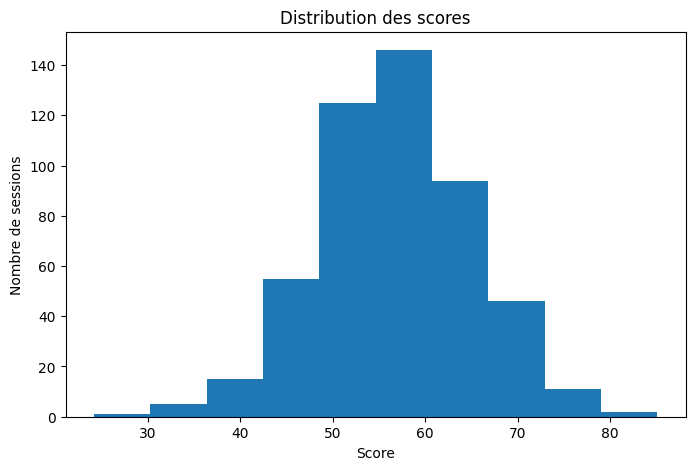

In [98]:
plt.figure(figsize=(8, 5))

plt.hist(
    session_analysis["score"],
    bins=10
)

plt.title("Distribution des scores")
plt.xlabel("Score")
plt.ylabel("Nombre de sessions")

plt.show()

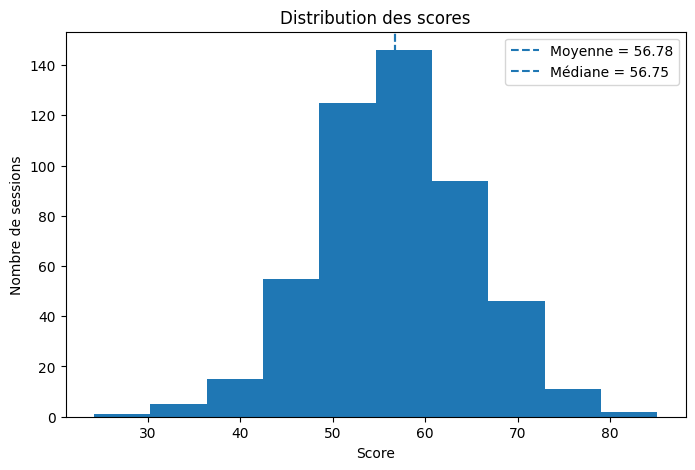

In [99]:
mean_score = session_analysis["score"].mean()
median_score = session_analysis["score"].median()

plt.figure(figsize=(8, 5))

plt.hist(
    session_analysis["score"],
    bins=10
)

plt.axvline(
    mean_score,
    linestyle="--",
    label=f"Moyenne = {mean_score:.2f}"
)

plt.axvline(
    median_score,
    linestyle="--",
    label=f"Médiane = {median_score:.2f}"
)

plt.title("Distribution des scores")
plt.xlabel("Score")
plt.ylabel("Nombre de sessions")
plt.legend()

plt.show()

In [100]:
print("Moyenne :", round(mean_score, 2))
print("Médiane :", round(median_score, 2))
print("Écart moyenne-médiane :", round(abs(mean_score - median_score), 2))

Moyenne : 56.78
Médiane : 56.75
Écart moyenne-médiane : 0.03


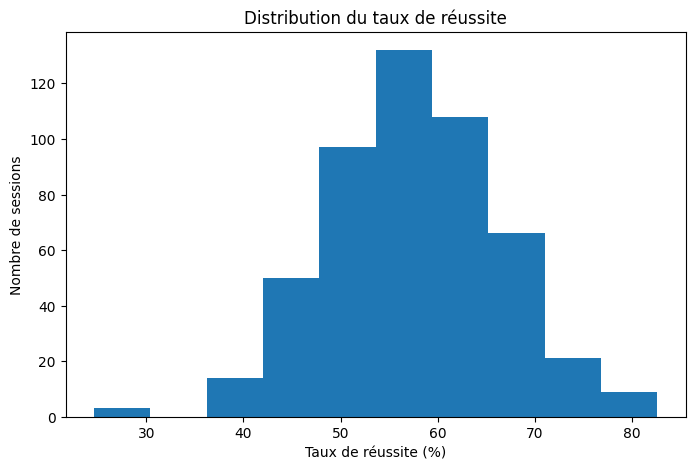

In [101]:
plt.figure(figsize=(8, 5))

plt.hist(
    session_analysis["success_rate"],
    bins=10
)

plt.title("Distribution du taux de réussite")
plt.xlabel("Taux de réussite (%)")
plt.ylabel("Nombre de sessions")

plt.show()

In [102]:
mean_success = session_analysis["success_rate"].mean()
median_success = session_analysis["success_rate"].median()

print("Moyenne :", round(mean_success, 2))
print("Médiane :", round(median_success, 2))
print(
    "Écart moyenne-médiane :",
    round(abs(mean_success - median_success), 2)
)

Moyenne : 57.34
Médiane : 57.25
Écart moyenne-médiane : 0.09


In [103]:
bins = [0, 32, 48, 60, 70, 80, 100]

success_groups = pd.cut(
    session_analysis["success_rate"],
    bins=bins,
    include_lowest=True
)

print(success_groups.value_counts().sort_index())

success_rate
(-0.001, 32.0]      3
(32.0, 48.0]       67
(48.0, 60.0]      247
(60.0, 70.0]      146
(70.0, 80.0]       33
(80.0, 100.0]       4
Name: count, dtype: int64


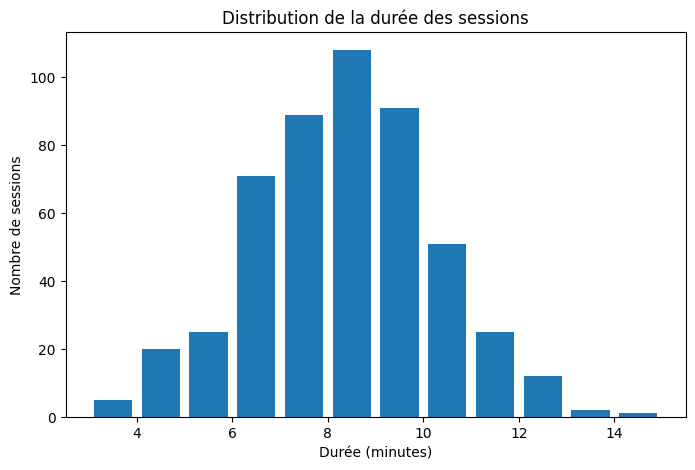

In [104]:
plt.figure(figsize=(8, 5))

plt.hist(
    session_analysis["duration"],
    bins=range(
        session_analysis["duration"].min(),
        session_analysis["duration"].max() + 2
    ),
    rwidth=0.8
)

plt.title("Distribution de la durée des sessions")
plt.xlabel("Durée (minutes)")
plt.ylabel("Nombre de sessions")

plt.show()

In [105]:
duration_counts = session_analysis["duration"].value_counts().sort_index()

print(duration_counts)

duration
3       5
4      20
5      25
6      71
7      89
8     108
9      91
10     51
11     25
12     12
13      2
14      1
Name: count, dtype: int64


In [106]:
most_common_duration = session_analysis["duration"].mode()[0]

print("Durée la plus fréquente :", most_common_duration, "minutes")

Durée la plus fréquente : 8 minutes


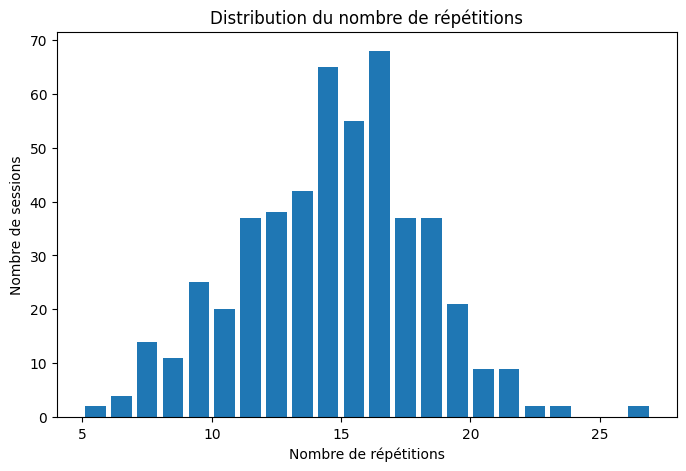

In [107]:
plt.figure(figsize=(8, 5))

plt.hist(
    session_analysis["repetitions"],
    bins=range(
        session_analysis["repetitions"].min(),
        session_analysis["repetitions"].max() + 2
    ),
    rwidth=0.8
)

plt.title("Distribution du nombre de répétitions")
plt.xlabel("Nombre de répétitions")
plt.ylabel("Nombre de sessions")

plt.show()

In [108]:
repetition_counts = (
    session_analysis["repetitions"]
    .value_counts()
    .sort_index()
)

print(repetition_counts)

repetitions
5      2
6      4
7     14
8     11
9     25
10    20
11    37
12    38
13    42
14    65
15    55
16    68
17    37
18    37
19    21
20     9
21     9
22     2
23     2
26     2
Name: count, dtype: int64


In [109]:
mean_repetitions = session_analysis["repetitions"].mean()
median_repetitions = session_analysis["repetitions"].median()
mode_repetitions = session_analysis["repetitions"].mode()[0]

print("Moyenne :", round(mean_repetitions, 2))
print("Médiane :", median_repetitions)
print("Mode :", mode_repetitions)

Moyenne : 14.16
Médiane : 14.0
Mode : 16


In [110]:
print(
    session_analysis["repetitions"].describe()
)

count    500.000000
mean      14.164000
std        3.490196
min        5.000000
25%       12.000000
50%       14.000000
75%       16.000000
max       26.000000
Name: repetitions, dtype: float64


In [111]:
number_of_patients = session_analysis["patient_id"].nunique()

print("Nombre de patients :", number_of_patients)

Nombre de patients : 20


In [112]:
sessions_per_patient = (
    session_analysis
    .groupby(["patient_id", "first_name", "last_name"])
    .size()
    .sort_values(ascending=False)
)

print(sessions_per_patient)

patient_id  first_name  last_name
6           Eya         Haddad       66
5           Zied        Gharbi       42
3           Fatma       Tlili        32
7           Yassine     Sassi        31
10          Maya        Trabelsi     30
18          Lina        Chaouch      30
1           Yasmine     Bouzid       26
11          Sirine      Ben Salah    26
4           Malek       Hamdi        26
9           Adam        Mejri        25
20          Omar        Dridi        25
2           Amira       Jebali       24
14          Ilyes       Belhaj       20
13          Nour        Zouari       16
16          Rayan       Mansouri     16
17          Skander     Karoui       16
15          Aymen       Nasri        15
8           Hiba        Khelifi      13
19          Mohamed     Slimani      12
12          Rim         Ayari         9
dtype: int64


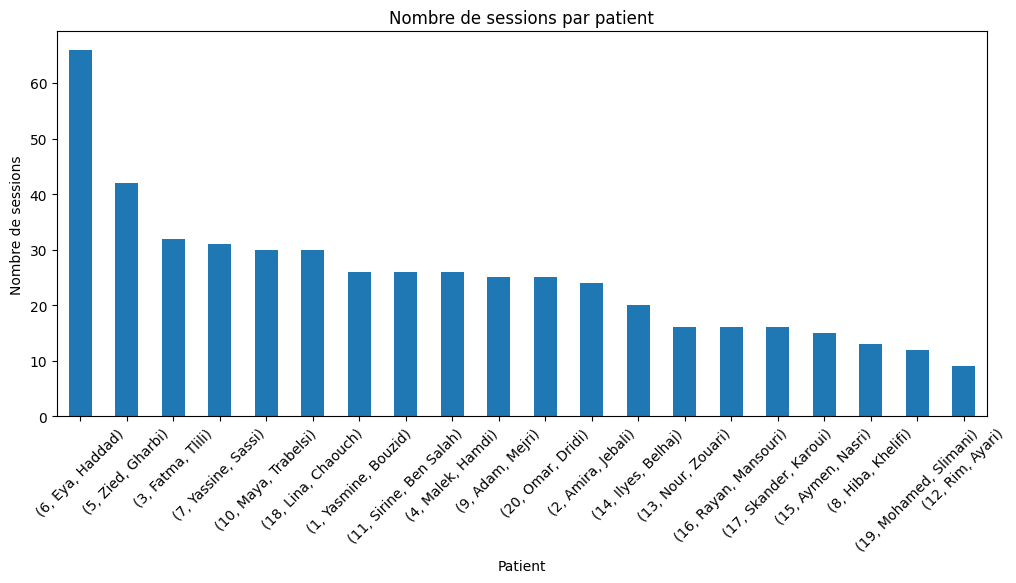

In [113]:
sessions_per_patient.plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Nombre de sessions par patient")
plt.xlabel("Patient")
plt.ylabel("Nombre de sessions")

plt.xticks(rotation=45)

plt.show()

In [114]:
mean_score_by_patient = (
    session_analysis
    .groupby(["patient_id", "first_name", "last_name"])["score"]
    .mean()
    .sort_values(ascending=False)
)

print(mean_score_by_patient)

patient_id  first_name  last_name
8           Hiba        Khelifi      64.069231
10          Maya        Trabelsi     61.270000
1           Yasmine     Bouzid       60.973077
19          Mohamed     Slimani      60.833333
6           Eya         Haddad       59.534848
5           Zied        Gharbi       59.166667
14          Ilyes       Belhaj       58.895000
13          Nour        Zouari       58.025000
7           Yassine     Sassi        57.832258
11          Sirine      Ben Salah    57.169231
15          Aymen       Nasri        56.473333
3           Fatma       Tlili        56.434375
16          Rayan       Mansouri     56.206250
9           Adam        Mejri        55.152000
4           Malek       Hamdi        55.061538
2           Amira       Jebali       54.941667
18          Lina        Chaouch      50.450000
17          Skander     Karoui       49.431250
20          Omar        Dridi        48.308000
12          Rim         Ayari        45.488889
Name: score, dtype: float6

In [115]:
mean_success_by_patient = (
    session_analysis
    .groupby(["patient_id", "first_name", "last_name"])["success_rate"]
    .mean()
    .sort_values(ascending=False)
)

print(mean_success_by_patient)

patient_id  first_name  last_name
8           Hiba        Khelifi      64.323077
19          Mohamed     Slimani      62.300000
1           Yasmine     Bouzid       60.907692
5           Zied        Gharbi       60.233333
6           Eya         Haddad       59.468182
3           Fatma       Tlili        59.268750
10          Maya        Trabelsi     59.206667
13          Nour        Zouari       58.831250
14          Ilyes       Belhaj       58.810000
16          Rayan       Mansouri     58.218750
7           Yassine     Sassi        58.077419
11          Sirine      Ben Salah    56.603846
2           Amira       Jebali       56.562500
9           Adam        Mejri        55.920000
4           Malek       Hamdi        55.611538
15          Aymen       Nasri        54.146667
17          Skander     Karoui       51.818750
18          Lina        Chaouch      51.633333
20          Omar        Dridi        49.784000
12          Rim         Ayari        46.455556
Name: success_rate, dtype:

In [116]:
patient_performance = (
    session_analysis
    .groupby(["patient_id", "first_name", "last_name"])
    .agg(
        sessions=("id_session", "count"),
        mean_score=("score", "mean"),
        mean_success_rate=("success_rate", "mean"),
        mean_repetitions=("repetitions", "mean"),
        mean_duration=("duration", "mean")
    )
    .reset_index()
)

patient_performance

,patient_id,first_name,last_name,sessions,mean_score,mean_success_rate,mean_repetitions,mean_duration
0,1,Yasmine,Bouzid,26,60.973077,60.907692,10.500000,6.615385
1,2,Amira,Jebali,24,54.941667,56.562500,12.333333,7.166667
2,3,Fatma,Tlili,32,56.434375,59.268750,17.843750,9.218750
3,4,Malek,Hamdi,26,55.061538,55.611538,17.038462,8.730769
4,5,Zied,Gharbi,42,59.166667,60.233333,13.571429,7.690476
5,6,Eya,Haddad,66,59.534848,59.468182,14.893939,7.727273
6,7,Yassine,Sassi,31,57.832258,58.077419,13.612903,8.032258
7,8,Hiba,Khelifi,13,64.069231,64.323077,11.692308,6.461538
8,9,Adam,Mejri,25,55.152000,55.920000,9.400000,6.080000
9,10,Maya,Trabelsi,30,61.270000,59.206667,10.666667,6.600000


In [117]:
patient_performance[
    [
        "mean_score",
        "mean_success_rate",
        "mean_repetitions",
        "mean_duration"
    ]
] = patient_performance[
    [
        "mean_score",
        "mean_success_rate",
        "mean_repetitions",
        "mean_duration"
    ]
].round(2)

patient_performance

,patient_id,first_name,last_name,sessions,mean_score,mean_success_rate,mean_repetitions,mean_duration
0,1,Yasmine,Bouzid,26,60.97,60.91,10.50,6.62
1,2,Amira,Jebali,24,54.94,56.56,12.33,7.17
2,3,Fatma,Tlili,32,56.43,59.27,17.84,9.22
3,4,Malek,Hamdi,26,55.06,55.61,17.04,8.73
4,5,Zied,Gharbi,42,59.17,60.23,13.57,7.69
5,6,Eya,Haddad,66,59.53,59.47,14.89,7.73
6,7,Yassine,Sassi,31,57.83,58.08,13.61,8.03
7,8,Hiba,Khelifi,13,64.07,64.32,11.69,6.46
8,9,Adam,Mejri,25,55.15,55.92,9.40,6.08
9,10,Maya,Trabelsi,30,61.27,59.21,10.67,6.60


In [118]:
number_of_exercises = session_analysis["exercise_id"].nunique()

print("Nombre d'exercices :", number_of_exercises)

Nombre d'exercices : 8


In [119]:
sessions_per_exercise = (
    session_analysis
    .groupby(["exercise_id", "name"])
    .size()
    .sort_values(ascending=False)
)

print(sessions_per_exercise)

exercise_id  name                       
8            Forearm Rotation               107
7            Wrist Flexion and Extension     92
6            Step Up                         79
5            Mini Squat                      62
1            Forward Arm Raise               57
4            Seated Knee Extension           56
2            Lateral Arm Raise               30
3            Overhead Reach                  17
dtype: int64


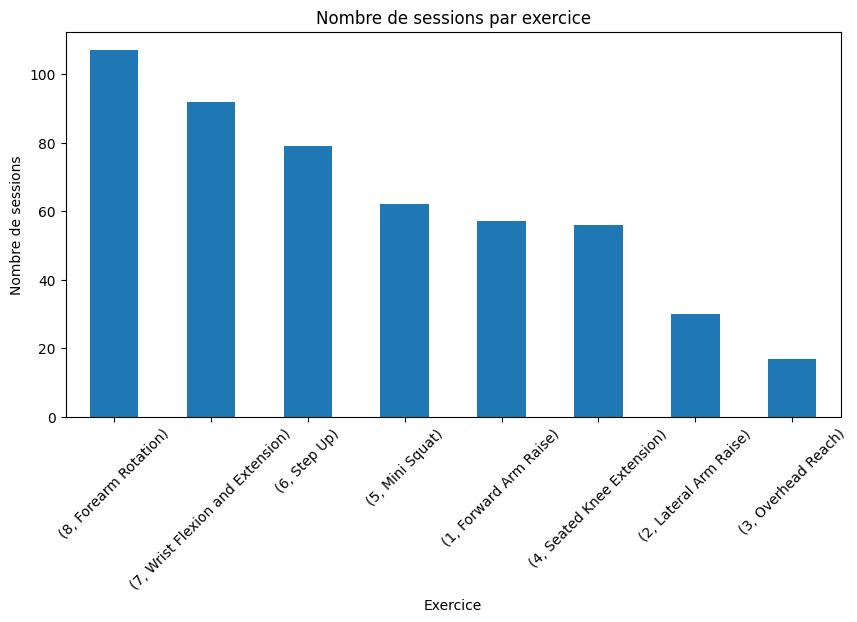

In [120]:
sessions_per_exercise.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Nombre de sessions par exercice")
plt.xlabel("Exercice")
plt.ylabel("Nombre de sessions")

plt.xticks(rotation=45)

plt.show()

In [121]:
exercise_performance = (
    session_analysis
    .groupby(["exercise_id", "name"])
    .agg(
        sessions=("id_session", "count"),
        mean_score=("score", "mean"),
        mean_success_rate=("success_rate", "mean"),
        mean_repetitions=("repetitions", "mean")
    )
    .reset_index()
)

exercise_performance[
    [
        "mean_score",
        "mean_success_rate",
        "mean_repetitions"
    ]
] = exercise_performance[
    [
        "mean_score",
        "mean_success_rate",
        "mean_repetitions"
    ]
].round(2)

exercise_performance

,exercise_id,name,sessions,mean_score,mean_success_rate,mean_repetitions
0,1,Forward Arm Raise,57,51.75,52.49,14.14
1,2,Lateral Arm Raise,30,60.43,61.29,14.50
2,3,Overhead Reach,17,50.45,53.78,14.94
3,4,Seated Knee Extension,56,59.24,59.92,13.14
4,5,Mini Squat,62,56.38,56.65,13.85
5,6,Step Up,79,58.37,58.65,13.85
6,7,Wrist Flexion and Extension,92,58.37,57.71,14.57
7,8,Forearm Rotation,107,55.84,57.15,14.56


In [122]:
number_of_games = session_analysis["game_id"].nunique()

print("Nombre de jeux :", number_of_games)

Nombre de jeux : 3


In [123]:
sessions_per_game = (
    session_analysis
    .groupby(["game_id", "name_game"])
    .size()
    .sort_values(ascending=False)
)

print(sessions_per_game)

game_id  name_game   
3        Wrist Wizard    199
2        Step Quest      197
1        Bubble Reach    104
dtype: int64


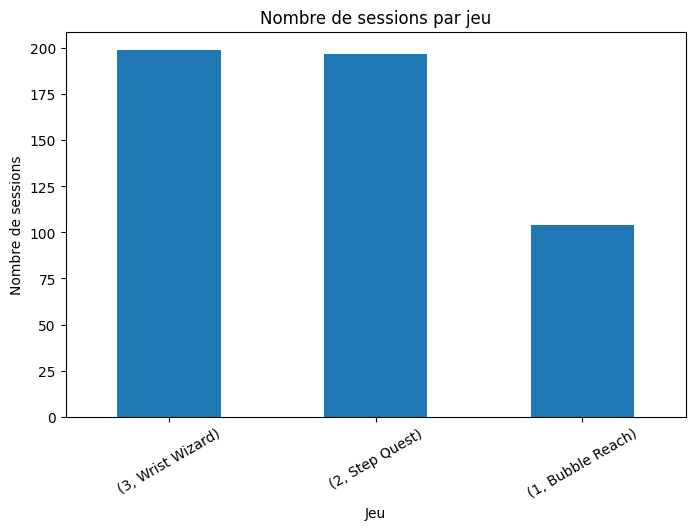

In [124]:
sessions_per_game.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Nombre de sessions par jeu")
plt.xlabel("Jeu")
plt.ylabel("Nombre de sessions")

plt.xticks(rotation=30)

plt.show()

In [125]:
game_performance = (
    session_analysis
    .groupby(["game_id", "name_game"])
    .agg(
        sessions=("id_session", "count"),
        mean_score=("score", "mean"),
        mean_success_rate=("success_rate", "mean"),
        mean_repetitions=("repetitions", "mean"),
        mean_duration=("duration", "mean")
    )
    .reset_index()
)

game_performance[
    [
        "mean_score",
        "mean_success_rate",
        "mean_repetitions",
        "mean_duration"
    ]
] = game_performance[
    [
        "mean_score",
        "mean_success_rate",
        "mean_repetitions",
        "mean_duration"
    ]
].round(2)

game_performance

,game_id,name_game,sessions,mean_score,mean_success_rate,mean_repetitions,mean_duration
0,1,Bubble Reach,104,54.04,55.24,14.38,7.95
1,2,Step Quest,197,57.99,58.38,13.65,7.56
2,3,Wrist Wizard,199,57.01,57.41,14.56,8.06


In [126]:
sessions_per_level = (
    session_analysis["level_number"]
    .value_counts()
    .sort_index()
)

print(sessions_per_level)

level_number
1     65
2    248
3    187
Name: count, dtype: int64


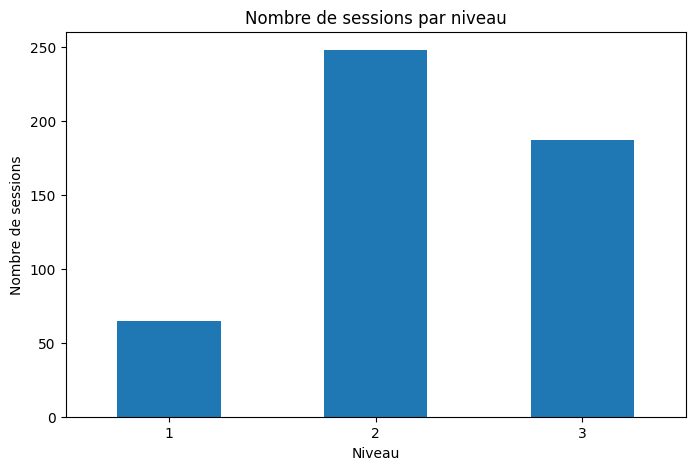

In [127]:
sessions_per_level.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Nombre de sessions par niveau")
plt.xlabel("Niveau")
plt.ylabel("Nombre de sessions")

plt.xticks(rotation=0)

plt.show()

In [128]:
level_performance = (
    session_analysis
    .groupby("level_number")
    .agg(
        sessions=("id_session", "count"),
        mean_score=("score", "mean"),
        mean_success_rate=("success_rate", "mean"),
        mean_repetitions=("repetitions", "mean")
    )
    .reset_index()
)

level_performance[
    [
        "mean_score",
        "mean_success_rate",
        "mean_repetitions"
    ]
] = level_performance[
    [
        "mean_score",
        "mean_success_rate",
        "mean_repetitions"
    ]
].round(2)

level_performance

,level_number,sessions,mean_score,mean_success_rate,mean_repetitions
0,1,65,51.98,53.45,16.11
1,2,248,56.05,56.82,14.29
2,3,187,59.41,59.38,13.32


In [129]:
progression_data = session_analysis[
    session_analysis["progression"].notna()
]["progression"]

print("Nombre de progressions disponibles :", len(progression_data))

Nombre de progressions disponibles : 457


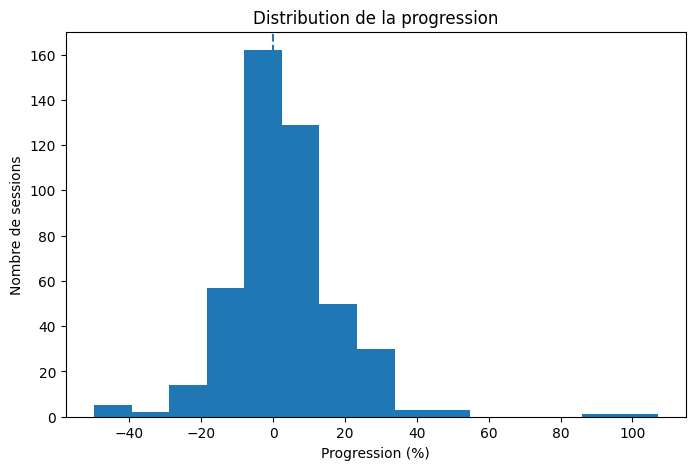

In [130]:
plt.figure(figsize=(8, 5))

plt.hist(
    progression_data,
    bins=15
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("Distribution de la progression")
plt.xlabel("Progression (%)")
plt.ylabel("Nombre de sessions")

plt.show()

In [131]:
mean_progression = progression_data.mean()
median_progression = progression_data.median()

print("Progression moyenne :", round(mean_progression, 2), "%")
print("Progression médiane :", round(median_progression, 2), "%")

Progression moyenne : 3.0 %
Progression médiane : 1.76 %


In [132]:
improved_sessions = (progression_data > 0).sum()
declined_sessions = (progression_data < 0).sum()
unchanged_sessions = (progression_data == 0).sum()

print("Sessions avec amélioration :", improved_sessions)
print("Sessions avec diminution :", declined_sessions)
print("Sessions sans changement :", unchanged_sessions)

Sessions avec amélioration : 260
Sessions avec diminution : 196
Sessions sans changement : 1


In [133]:
total_progression_sessions = len(progression_data)

improved_percentage = (
    improved_sessions / total_progression_sessions * 100
)

declined_percentage = (
    declined_sessions / total_progression_sessions * 100
)

unchanged_percentage = (
    unchanged_sessions / total_progression_sessions * 100
)

print(
    "Amélioration :",
    round(improved_percentage, 2),
    "%"
)

print(
    "Diminution :",
    round(declined_percentage, 2),
    "%"
)

print(
    "Sans changement :",
    round(unchanged_percentage, 2),
    "%"
)

Amélioration : 56.89 %
Diminution : 42.89 %
Sans changement : 0.22 %


In [134]:
patient_id_example = session_analysis["patient_id"].iloc[0]

print("Patient sélectionné :", patient_id_example)

Patient sélectionné : 1


In [135]:
patient_sessions = (
    session_analysis[
        session_analysis["patient_id"] == patient_id_example
    ]
    .sort_values("session_date")
)

patient_sessions[
    [
        "session_date",
        "name",
        "level_number",
        "score",
        "success_rate",
        "repetitions",
        "progression"
    ]
]

,session_date,name,level_number,score,success_rate,repetitions,progression
0,2026-04-30 15:50:31,Wrist Flexion and Extension,3,60.6,60.2,9,NaN
1,2026-05-04 15:00:15,Wrist Flexion and Extension,3,52.5,52.7,9,-13.37
13,2026-05-05 15:20:38,Forearm Rotation,2,47.1,52.7,10,NaN
2,2026-05-07 15:00:09,Wrist Flexion and Extension,3,63.8,68.7,10,21.52
14,2026-05-08 15:20:48,Forearm Rotation,2,48.7,61.3,13,3.40
3,2026-05-12 15:10:22,Wrist Flexion and Extension,3,60.3,59.0,6,-5.49
15,2026-05-12 15:55:04,Forearm Rotation,2,57.5,62.4,7,18.07
4,2026-05-16 10:45:20,Wrist Flexion and Extension,3,62.7,70.3,11,3.98
16,2026-05-18 15:00:36,Forearm Rotation,2,52.9,55.8,9,-8.00
5,2026-05-21 15:40:50,Wrist Flexion and Extension,3,61.0,60.4,14,-2.71


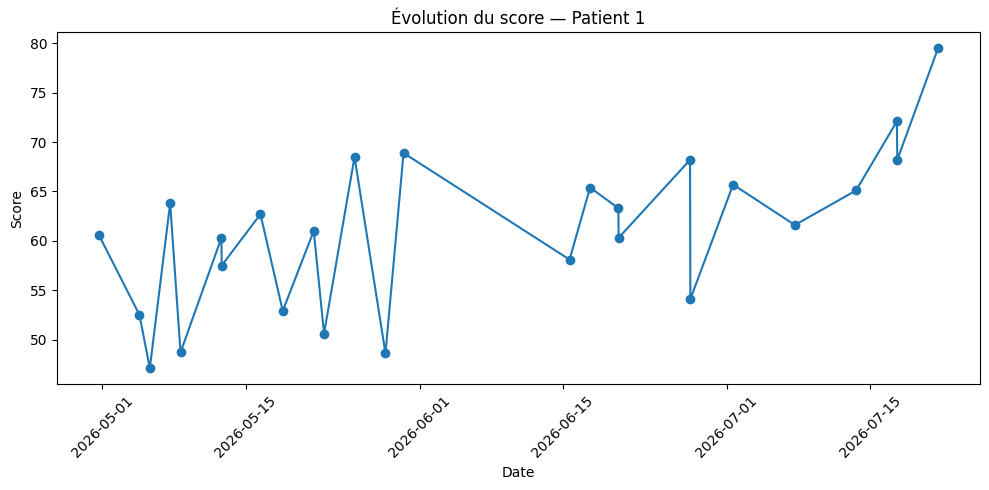

In [136]:
plt.figure(figsize=(10, 5))

plt.plot(
    patient_sessions["session_date"],
    patient_sessions["score"],
    marker="o"
)

plt.title(
    f"Évolution du score — Patient {patient_id_example}"
)

plt.xlabel("Date")
plt.ylabel("Score")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

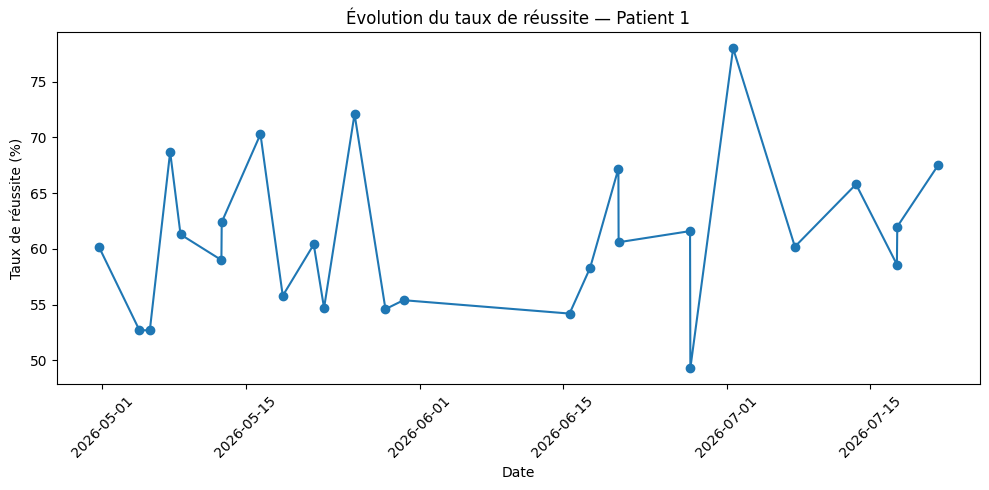

In [137]:
plt.figure(figsize=(10, 5))

plt.plot(
    patient_sessions["session_date"],
    patient_sessions["success_rate"],
    marker="o"
)

plt.title(
    f"Évolution du taux de réussite — Patient {patient_id_example}"
)

plt.xlabel("Date")
plt.ylabel("Taux de réussite (%)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

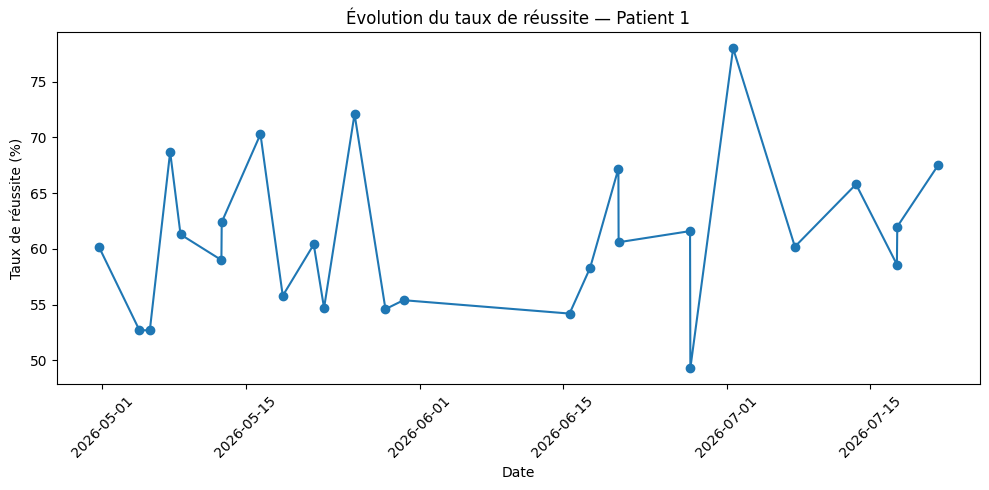

In [138]:
plt.figure(figsize=(10, 5))

plt.plot(
    patient_sessions["session_date"],
    patient_sessions["success_rate"],
    marker="o"
)

plt.title(
    f"Évolution du taux de réussite — Patient {patient_id_example}"
)

plt.xlabel("Date")
plt.ylabel("Taux de réussite (%)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

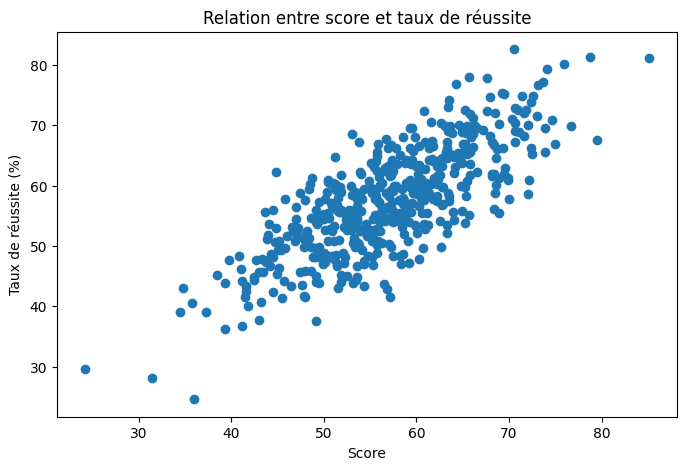

In [139]:
plt.figure(figsize=(8, 5))

plt.scatter(
    session_analysis["score"],
    session_analysis["success_rate"]
)

plt.title("Relation entre score et taux de réussite")
plt.xlabel("Score")
plt.ylabel("Taux de réussite (%)")

plt.show()

In [140]:
score_success_correlation = (
    session_analysis["score"]
    .corr(session_analysis["success_rate"])
)

print(
    "Corrélation score / taux de réussite :",
    round(score_success_correlation, 3)
)

Corrélation score / taux de réussite : 0.773


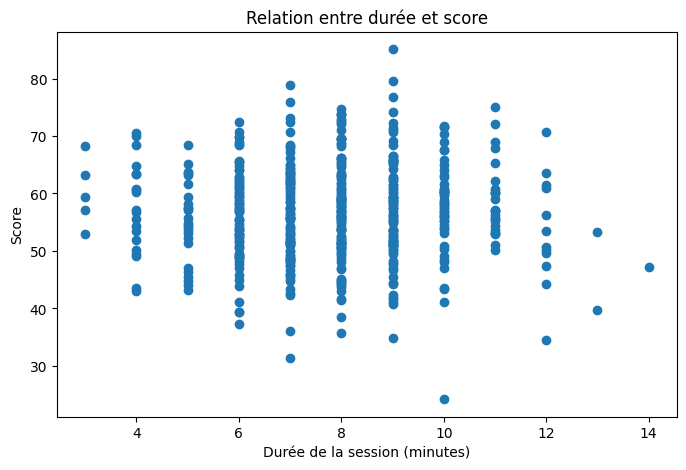

In [141]:
plt.figure(figsize=(8, 5))

plt.scatter(
    session_analysis["duration"],
    session_analysis["score"]
)

plt.title("Relation entre durée et score")
plt.xlabel("Durée de la session (minutes)")
plt.ylabel("Score")

plt.show()

In [142]:
duration_score_correlation = (
    session_analysis["duration"]
    .corr(session_analysis["score"])
)

print(
    "Corrélation durée / score :",
    round(duration_score_correlation, 3)
)

Corrélation durée / score : 0.012


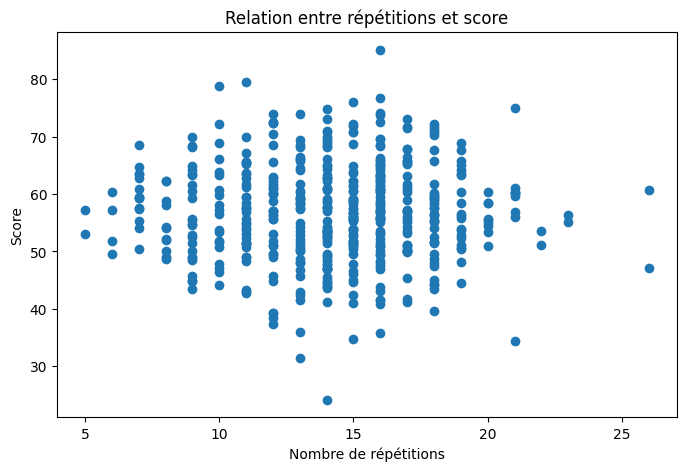

In [143]:
plt.figure(figsize=(8, 5))

plt.scatter(
    session_analysis["repetitions"],
    session_analysis["score"]
)

plt.title("Relation entre répétitions et score")
plt.xlabel("Nombre de répétitions")
plt.ylabel("Score")

plt.show()

In [144]:
repetitions_score_correlation = (
    session_analysis["repetitions"]
    .corr(session_analysis["score"])
)

print(
    "Corrélation répétitions / score :",
    round(repetitions_score_correlation, 3)
)

Corrélation répétitions / score : 0.012


In [145]:
top_sessions = (
    session_analysis[
        [
            "id_session",
            "patient_id",
            "first_name",
            "last_name",
            "name",
            "name_game",
            "level_number",
            "score",
            "success_rate"
        ]
    ]
    .sort_values("score", ascending=False)
    .head(10)
)

top_sessions

,id_session,patient_id,first_name,last_name,name,name_game,level_number,score,success_rate
344,163,14,Ilyes,Belhaj,Wrist Flexion and Extension,Wrist Wizard,3,85.1,81.2
12,166,1,Yasmine,Bouzid,Wrist Flexion and Extension,Wrist Wizard,3,79.5,67.5
351,398,14,Ilyes,Belhaj,Wrist Flexion and Extension,Wrist Wizard,3,78.8,81.3
347,200,14,Ilyes,Belhaj,Wrist Flexion and Extension,Wrist Wizard,3,76.7,69.8
202,494,6,Eya,Haddad,Step Up,Step Quest,3,76.0,80.2
200,470,6,Eya,Haddad,Step Up,Step Quest,3,75.0,66.9
144,461,10,Maya,Trabelsi,Seated Knee Extension,Step Quest,3,74.7,70.9
453,357,18,Lina,Chaouch,Wrist Flexion and Extension,Wrist Wizard,2,74.1,79.4
197,384,6,Eya,Haddad,Step Up,Step Quest,3,73.9,65.6
288,497,5,Zied,Gharbi,Mini Squat,Step Quest,3,73.9,69.6


In [146]:
lowest_sessions = (
    session_analysis[
        [
            "id_session",
            "patient_id",
            "first_name",
            "last_name",
            "name",
            "name_game",
            "level_number",
            "score",
            "success_rate"
        ]
    ]
    .sort_values("score", ascending=True)
    .head(10)
)

lowest_sessions

,id_session,patient_id,first_name,last_name,name,name_game,level_number,score,success_rate
243,229,18,Lina,Chaouch,Forearm Rotation,Wrist Wizard,2,24.2,29.6
238,97,18,Lina,Chaouch,Forearm Rotation,Wrist Wizard,2,31.4,28.1
363,346,18,Lina,Chaouch,Seated Knee Extension,Step Quest,2,34.5,39.0
359,264,18,Lina,Chaouch,Seated Knee Extension,Step Quest,2,34.8,43.0
364,377,18,Lina,Chaouch,Seated Knee Extension,Step Quest,2,35.8,40.5
239,106,18,Lina,Chaouch,Forearm Rotation,Wrist Wizard,2,36.0,24.6
454,379,18,Lina,Chaouch,Wrist Flexion and Extension,Wrist Wizard,2,37.3,39.0
366,190,5,Zied,Gharbi,Forward Arm Raise,Bubble Reach,3,38.5,45.2
249,142,6,Eya,Haddad,Forward Arm Raise,Bubble Reach,3,39.3,36.2
303,156,4,Malek,Hamdi,Forearm Rotation,Wrist Wizard,1,39.3,43.8


In [147]:
highest_progressions = (
    session_analysis[
        session_analysis["progression"].notna()
    ]
    .sort_values("progression", ascending=False)
    .head(10)
)

highest_progressions[
    [
        "id_session",
        "patient_id",
        "first_name",
        "last_name",
        "name",
        "score",
        "progression"
    ]
]

,id_session,patient_id,first_name,last_name,name,score,progression
244,245,18,Lina,Chaouch,Forearm Rotation,50.1,107.02
360,279,18,Lina,Chaouch,Seated Knee Extension,67.9,95.11
351,398,14,Ilyes,Belhaj,Wrist Flexion and Extension,78.8,53.01
358,236,18,Lina,Chaouch,Seated Knee Extension,69.4,52.53
240,123,18,Lina,Chaouch,Forearm Rotation,53.5,48.61
365,409,18,Lina,Chaouch,Seated Knee Extension,50.0,39.66
304,173,4,Malek,Hamdi,Forearm Rotation,54.0,37.40
459,298,14,Ilyes,Belhaj,Forearm Rotation,54.5,37.28
473,466,16,Rayan,Mansouri,Mini Squat,56.3,32.78
29,34,3,Fatma,Tlili,Forearm Rotation,55.5,32.78


In [148]:
lowest_progressions = (
    session_analysis[
        session_analysis["progression"].notna()
    ]
    .sort_values("progression", ascending=True)
    .head(10)
)

lowest_progressions[
    [
        "id_session",
        "patient_id",
        "first_name",
        "last_name",
        "name",
        "score",
        "progression"
    ]
]

,id_session,patient_id,first_name,last_name,name,score,progression
359,264,18,Lina,Chaouch,Seated Knee Extension,34.8,-49.86
454,379,18,Lina,Chaouch,Wrist Flexion and Extension,37.3,-49.66
243,229,18,Lina,Chaouch,Forearm Rotation,24.2,-49.48
348,223,14,Ilyes,Belhaj,Wrist Flexion and Extension,43.3,-43.55
363,346,18,Lina,Chaouch,Seated Knee Extension,34.5,-41.82
437,303,13,Nour,Zouari,Forearm Rotation,44.3,-34.47
361,301,18,Lina,Chaouch,Seated Knee Extension,44.8,-34.02
345,170,14,Ilyes,Belhaj,Wrist Flexion and Extension,60.7,-28.67
410,325,13,Nour,Zouari,Wrist Flexion and Extension,46.9,-26.14
28,27,3,Fatma,Tlili,Forearm Rotation,41.8,-25.09


In [149]:
eda_summary = pd.DataFrame({
    "Indicateur": [
        "Nombre de patients",
        "Nombre de jeux",
        "Nombre d'exercices",
        "Nombre de sessions",
        "Score moyen",
        "Score médian",
        "Taux de réussite moyen",
        "Taux de réussite médian",
        "Durée moyenne",
        "Durée médiane",
        "Répétitions moyennes",
        "Répétitions médianes",
        "Progression moyenne",
        "Progression médiane"
    ],
    "Valeur": [
        session_analysis["patient_id"].nunique(),
        session_analysis["game_id"].nunique(),
        session_analysis["exercise_id"].nunique(),
        len(session_analysis),
        session_analysis["score"].mean(),
        session_analysis["score"].median(),
        session_analysis["success_rate"].mean(),
        session_analysis["success_rate"].median(),
        session_analysis["duration"].mean(),
        session_analysis["duration"].median(),
        session_analysis["repetitions"].mean(),
        session_analysis["repetitions"].median(),
        session_analysis["progression"].mean(),
        session_analysis["progression"].median()
    ]
})

eda_summary["Valeur"] = eda_summary["Valeur"].round(2)

eda_summary

,Indicateur,Valeur
0,Nombre de patients,20.00
1,Nombre de jeux,3.00
2,Nombre d'exercices,8.00
3,Nombre de sessions,500.00
4,Score moyen,56.78
5,Score médian,56.75
6,Taux de réussite moyen,57.34
7,Taux de réussite médian,57.25
8,Durée moyenne,7.84
9,Durée médiane,8.00


In [ ]:
print("===== PREMIERS INSIGHTS =====")

print(
    f"• {session_analysis['patient_id'].nunique()} patients "
    f"ont réalisé {len(session_analysis)} sessions."
)

print(
    f"• Le score moyen est de "
    f"{session_analysis['score'].mean():.2f}."
)

print(
    f"• Le taux de réussite moyen est de "
    f"{session_analysis['success_rate'].mean():.2f}%."
)

print(
    f"• La durée moyenne d'une session est de "
    f"{session_analysis['duration'].mean():.2f} minutes."
)

print(
    f"• Le nombre moyen de répétitions est de "
    f"{session_analysis['repetitions'].mean():.2f}."
)

print(
    f"• La progression moyenne observée est de "
    f"{session_analysis['progression'].mean():.2f}%."
)

print(
    f"• {improved_percentage:.2f}% des sessions avec progression "
    f"montrent une amélioration."
)

print(
    f"• {declined_percentage:.2f}% des sessions avec progression "
    f"montrent une diminution."
)

===== PREMIERS INSIGHTS =====
• 20 patients ont réalisé 500 sessions.
• Le score moyen est de 56.78.
• Le taux de réussite moyen est de 57.34%.
• La durée moyenne d'une session est de 7.84 minutes.
• Le nombre moyen de répétitions est de 14.16.
• La progression moyenne observée est de 3.00%.
• 56.89% des sessions avec progression montrent une amélioration.
• 42.89% des sessions avec progression montrent une diminution.


: 

# Conclusion

L'analyse exploratoire des données a permis de mieux comprendre
les caractéristiques des sessions de rééducation et les performances
des patients.

Les principales dimensions étudiées sont :

- les scores ;
- les taux de réussite ;
- la durée des sessions ;
- le nombre de répétitions ;
- les patients ;
- les exercices ;
- les jeux ;
- les niveaux ;
- l'évolution des performances.

L'analyse a également permis d'identifier les distributions des
principales variables et d'étudier certaines relations entre les
indicateurs de performance.

Les analyses de progression permettent notamment de distinguer les
sessions associées à une amélioration, une diminution ou une absence
de changement du score.

Les résultats obtenus dans ce notebook constituent une première base
pour définir les KPI et les indicateurs qui seront utilisés dans le
dashboard destiné aux thérapeutes.

Les conclusions définitives concernant les performances des patients
seront approfondies dans les notebooks suivants, notamment lors de
l'analyse des KPI et de la progression individuelle.